# Recognizing When to Use PCA in Security Analytics

**Goal:** learn how to recognize redundant high-dimensional data, decide whether PCA is appropriate, and use scikit-learn to create a smaller representation for visualization and analysis.

> PCA is unsupervised: scenario labels below are used only to interpret the final projection, never to fit PCA.

## 1. How do we recognize that PCA may help?

PCA is worth investigating when:

- the dataset has many numeric features, making direct visualization difficult;
- several features are strongly correlated and appear to measure overlapping behavior;
- models or distance calculations suffer from redundant dimensions;
- we need a compact representation for visualization, clustering, or storage.

PCA is **not automatically required** when features are correlated. We should verify that a small number of components retain enough variance and that losing feature-level interpretability is acceptable.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 207
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Example: overlapping security telemetry

The six observed features describe activity volume, destination spread, and connection failures. In a real investigation, we would first inspect whether these columns repeat similar information before reaching for PCA.

In [16]:
n = 480
scenario = rng.choice(['routine', 'scan-like', 'transfer-heavy'], n, p=[0.55, 0.25, 0.20])
scenario_effects = {
    'routine': (0.0, 0.0, 0.0),
    'scan-like': (0.5, 2.1, 1.2),
    'transfer-heavy': (2.4, 0.4, 0.3),
}
effects = np.array([scenario_effects[name] for name in scenario])
volume = rng.normal(0, 1, n) + effects[:, 0]
spread = rng.normal(0, 0.8, n) + 0.35 * volume + effects[:, 1]
failure = rng.normal(0, 0.7, n) + 0.20 * spread + effects[:, 2]
telemetry = pd.DataFrame({
    'log_bytes': 7.5 + 1.2 * volume + rng.normal(0, 0.25, n),
    'request_rate': 42 + 13 * volume + 3 * spread + rng.normal(0, 2.5, n),
    'unique_destinations': 18 + 2 * volume + 8 * spread + rng.normal(0, 1.8, n),
    'destination_ports': 7 + 1.5 * volume + 5 * spread + rng.normal(0, 1.2, n),
    'failed_connections': 3 + 1.2 * spread + 4 * failure + rng.normal(0, 0.8, n),
    'alert_count': 2 + 0.8 * volume + 1.1 * spread + 2.2 * failure + rng.normal(0, 0.7, n),
}).clip(lower=0)
telemetry.head()

,log_bytes,request_rate,unique_destinations,destination_ports,failed_connections,alert_count
0,8.697578,51.909155,29.757228,16.040634,11.405721,8.321629
1,7.346441,40.926002,19.299759,7.140571,6.433439,3.575656
2,10.381160,76.055433,42.110814,22.902997,4.690951,4.829413
3,7.817234,50.506286,22.609691,12.190066,9.280164,5.669125
4,11.006385,84.738444,36.475394,18.931167,9.548857,7.870490


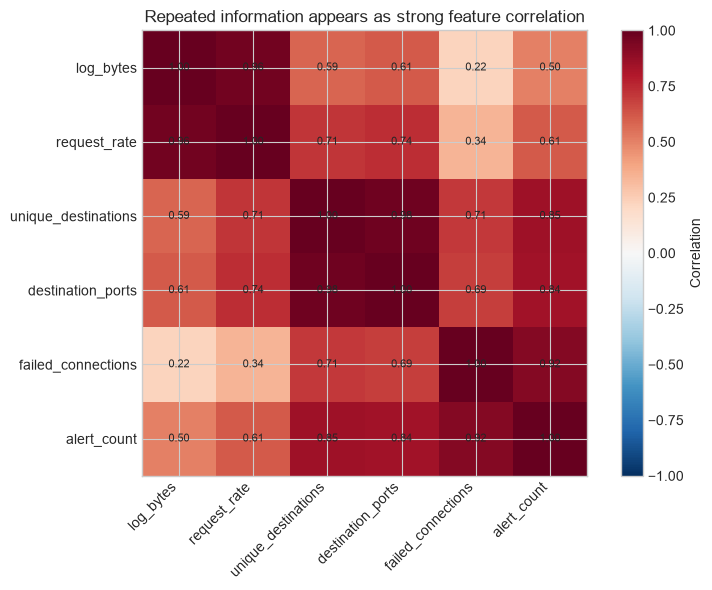

Feature count: 6
Pairs with |correlation| >= 0.80: 5


,,correlation
unique_destinations,destination_ports,0.975216
log_bytes,request_rate,0.961408
failed_connections,alert_count,0.916313
unique_destinations,alert_count,0.846043
destination_ports,alert_count,0.839786


In [17]:
correlation = telemetry.corr()
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
strong_pairs = (
    upper_triangle.stack()
    .loc[lambda values: values.abs() >= 0.80]
    .sort_values(key=np.abs, ascending=False)
    .rename('correlation')
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
ax.set_yticks(range(len(correlation.columns)), correlation.columns)
for row in range(len(correlation)):
    for column in range(len(correlation)):
        ax.text(column, row, f'{correlation.iloc[row, column]:.2f}',
                ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, label='Correlation')
ax.set_title('Repeated information appears as strong feature correlation')
plt.tight_layout()
plt.show()

print(f'Feature count: {telemetry.shape[1]}')
print(f'Pairs with |correlation| >= 0.80: {len(strong_pairs)}')
display(strong_pairs.to_frame())

## 3. Standardize before PCA

PCA compares variance across features. Because bytes, rates, and counts use different units, standardization ensures that a large numeric scale does not determine the components. In a predictive workflow, fit the scaler and PCA on training data only.

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(telemetry)
print('Means after scaling:', np.round(X_scaled.mean(axis=0), 3))
print('Std devs after scaling:', np.round(X_scaled.std(axis=0), 3))

Means after scaling: [-0. -0.  0.  0.  0. -0.]
Std devs after scaling: [1. 1. 1. 1. 1. 1.]


## 4. Try PCA and measure whether compression is worthwhile

Fit PCA with all components first. The cumulative explained-variance curve answers the practical question: **how many components are needed to preserve most of the dataset's variation?** A common starting threshold is 90% or 95%, but the acceptable loss depends on the task.

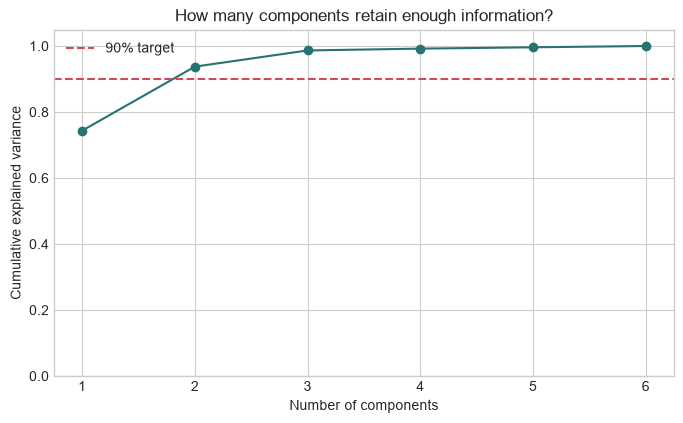

,component,individual_variance,cumulative_variance
0,1,0.743,0.743
1,2,0.194,0.938
2,3,0.049,0.987
3,4,0.006,0.992
4,5,0.004,0.996
5,6,0.004,1.000


In [19]:
full_pca = PCA().fit(X_scaled)
component_numbers = np.arange(1, telemetry.shape[1] + 1)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)
variance_summary = pd.DataFrame({
    'component': component_numbers,
    'individual_variance': full_pca.explained_variance_ratio_,
    'cumulative_variance': cumulative_variance,
})

plt.figure(figsize=(8, 4.5))
plt.plot(component_numbers, cumulative_variance, marker='o', color='#287271')
plt.axhline(0.90, linestyle='--', color='#d1495b', label='90% target')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.ylim(0, 1.05)
plt.xticks(component_numbers)
plt.title('How many components retain enough information?')
plt.legend()
plt.show()

display(variance_summary.round(3))

## 5. Build the compact representation

Let scikit-learn select the smallest number of components that reaches the 90% target. This avoids hard-coding a component count before looking at the data.

In [20]:
compact_pca = PCA(n_components=0.90)
X_compact = compact_pca.fit_transform(X_scaled)

print(f'Original shape: {X_scaled.shape}')
print(f'Reduced shape:  {X_compact.shape}')
print(f'Variance retained: {compact_pca.explained_variance_ratio_.sum():.1%}')
print(f'Components selected: {compact_pca.n_components_}')

compact_telemetry = pd.DataFrame(
    X_compact,
    columns=[f'PC{index + 1}' for index in range(compact_pca.n_components_)],
)
compact_telemetry.head()

Original shape: (480, 6)
Reduced shape:  (480, 2)
Variance retained: 93.8%
Components selected: 2


,PC1,PC2
0,1.163374,-0.775001
1,-1.255733,-0.426214
2,2.033675,1.332261
3,-0.051450,-0.577522
4,2.599764,1.066714


## 6. Use PCA for investigation and visualization

Component loadings help analysts understand the compressed axes. Large absolute values identify the original features that most influence a component. The sign gives direction, but PCA signs may flip without changing the result.

In [21]:
loadings = pd.DataFrame(
    compact_pca.components_.T,
    index=telemetry.columns,
    columns=compact_telemetry.columns,
)

print('Features with the strongest influence on each component:')
for component in loadings.columns:
    strongest = loadings[component].abs().nlargest(3).index.tolist()
    print(f'{component}: {", ".join(strongest)}')

display(loadings.round(3))

Features with the strongest influence on each component:
PC1: destination_ports, unique_destinations, alert_count
PC2: log_bytes, failed_connections, request_rate


,PC1,PC2
log_bytes,0.351,0.592
request_rate,0.397,0.487
unique_destinations,0.447,-0.096
destination_ports,0.449,-0.064
failed_connections,0.358,-0.554
alert_count,0.434,-0.302


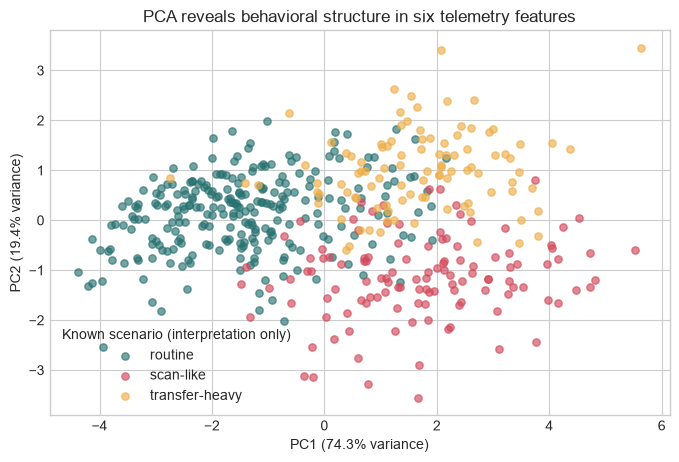

In [22]:
colors = {'routine': '#287271', 'scan-like': '#d1495b', 'transfer-heavy': '#edae49'}
plt.figure(figsize=(8, 5))
for name, color in colors.items():
    mask = scenario == name
    plt.scatter(X_compact[mask, 0], X_compact[mask, 1],
                s=28, alpha=0.65, color=color, label=name)
plt.xlabel(f'PC1 ({compact_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({compact_pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA reveals behavioral structure in six telemetry features')
plt.legend(title='Known scenario (interpretation only)')
plt.show()

## 7. Did PCA earn its place?

A useful reduction should preserve enough variation, substantially reduce dimensionality, and support the intended task. Reconstruction error provides a concrete view of what the two-component representation loses.

In [23]:
X_reconstructed = compact_pca.inverse_transform(X_compact)
feature_rmse = pd.Series(
    np.sqrt(np.mean((X_scaled - X_reconstructed) ** 2, axis=0)),
    index=telemetry.columns,
    name='reconstruction_rmse',
)

print(f'Dimensions removed: {telemetry.shape[1] - compact_pca.n_components_} of {telemetry.shape[1]}')
print(f'Variance retained: {compact_pca.explained_variance_ratio_.sum():.1%}')
print(f'Overall standardized RMSE: {np.sqrt(np.mean((X_scaled - X_reconstructed) ** 2)):.3f}')
display(feature_rmse.sort_values(ascending=False).to_frame().round(3))

Dimensions removed: 4 of 6
Variance retained: 93.8%
Overall standardized RMSE: 0.250


,reconstruction_rmse
unique_destinations,0.310
destination_ports,0.307
failed_connections,0.265
alert_count,0.231
log_bytes,0.202
request_rate,0.141


## 8. Practical decision checklist

Use PCA when the answers are mostly **yes**:

- Are there many numeric features or several strongly correlated pairs?
- Does a small number of components retain an acceptable amount of variance?
- Does the reduced data improve visualization, clustering, speed, or storage?
- Can the workflow tolerate components being less interpretable than original features?

Avoid or reconsider PCA when individual feature explanations are required, the useful signal has low variance, categorical features dominate, or nonlinear structure matters. PCA is an experiment to validate, not a mandatory response to correlation.